# Final Project Analysis

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [38]:
df = pd.read_csv('cleaned_spotify.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112337 entries, 0 to 112336
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          112337 non-null  object 
 1   artists           112337 non-null  object 
 2   album_name        112337 non-null  object 
 3   track_name        112337 non-null  object 
 4   popularity        112337 non-null  int64  
 5   duration_ms       112337 non-null  int64  
 6   explicit          112337 non-null  bool   
 7   danceability      112337 non-null  float64
 8   energy            112337 non-null  float64
 9   key               112337 non-null  int64  
 10  loudness          112337 non-null  float64
 11  mode              112337 non-null  int64  
 12  speechiness       112337 non-null  float64
 13  acousticness      112337 non-null  float64
 14  instrumentalness  112337 non-null  float64
 15  liveness          112337 non-null  float64
 16  valence           11

## Multiple Linear Regression: Predicting Popularity

In [39]:
#Feature Selection: numerical features to predict 'popularity'
features = ['danceability', 'energy', 'loudness', 'speechiness', 
            'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
X = df[features]
y = df['popularity']

#Check for Multicollinearity (VIF)
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print("VIF Results (Ideally < 5-10):\n", vif_data)

#Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Fit Model using Statsmodels (better for p-values/interpretation)
X_train_const = sm.add_constant(X_train) 
model = sm.OLS(y_train, X_train_const).fit()
print(model.summary())

VIF Results (Ideally < 5-10):
             feature        VIF
0      danceability  12.446079
1            energy  15.268944
2          loudness   7.164117
3       speechiness   1.807298
4      acousticness   3.568545
5  instrumentalness   1.761088
6          liveness   2.574076
7           valence   6.541496
8             tempo  15.462227
                            OLS Regression Results                            
Dep. Variable:             popularity   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     232.1
Date:                Wed, 22 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:23:58   Log-Likelihood:            -4.0559e+05
No. Observations:               89869   AIC:                         8.112e+05
Df Residuals:                   89859   BIC:                         8.113e+05
Df Model:                  


- **VIF Issue**: danceability, energy, and tempo all have VIFs > 10 so are highly correlated with each other. When variables are collinear, the model struggles to decide which is actually responsible for change in popularity. Energy and loudness are often related in music, which explains why model is flagging high multicollinearity.
- **P-Values Low**: Despite the multicollinearity, almost every feature has a P-value of 0.000. This means every feature chosen is a statistically significant predictor of popularity. The exception is that acousticness has a P-value of 0.015. While still significant (below 0.05), it is the "weakest" predictor in the set.
- **R-squared Low**: The R-squared is 0.023. The model only explains 2.3% of the variance in song popularity. While audio features like danceability and energy are statistically significant, they only account for 2% of a song's success. This suggests that external factors like artist fame, marketing budgets, and social media trends are more influential than explanation of the music.
- **Interpreting the Coefficients**: What makes a song popular according to the model?:
Danceability is the strongest positive predictor. Speechiness is the strongest negative predictor. Songs with more spoken words (like podcasts or rap-heavy tracks) in this specific dataset tend to have lower general popularity scores. Instrumentalness is negative. (Purely instrumental tracks are generally less popular than vocal tracks). Valence is negative (High valence means "cheerful." The model suggests that in this dataset, "sad" or "darker" songs (lower valence) are actually more popular.)

## Logistic Regression: Predicting Popularity

In [49]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

#Do median split for balanced dataset 
median_pop = df['popularity'].median()
df['is_popular'] = (df['popularity'] > median_pop).astype(int)

#Dummy Code 'key' feature
X = pd.get_dummies(df[['key', 'danceability', 'energy', 'loudness', 'valence']], columns=['key'], drop_first=True)
y = df['is_popular']

#Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Fit Logistic Regression
model_pop = LogisticRegression(max_iter=1000)
model_pop.fit(X_train, y_train)

#Evaluate
y_pred = model_pop.predict(X_test)
y_prob = model_pop.predict_proba(X_test)[:, 1]

print(f"Predicting High Popularity (Threshold: {median_pop}):")
print("- Accuracy:", model_pop.score(X_test, y_test))
print("- ROC-AUC Score:", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Predicting High Popularity (Threshold: 35.0):
- Accuracy: 0.5660494926117144
- ROC-AUC Score: 0.5831511533535009

Confusion Matrix:
 [[7006 4530]
 [5220 5712]]

Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.61      0.59     11536
           1       0.56      0.52      0.54     10932

    accuracy                           0.57     22468
   macro avg       0.57      0.56      0.56     22468
weighted avg       0.57      0.57      0.57     22468



## K-Means Clustering

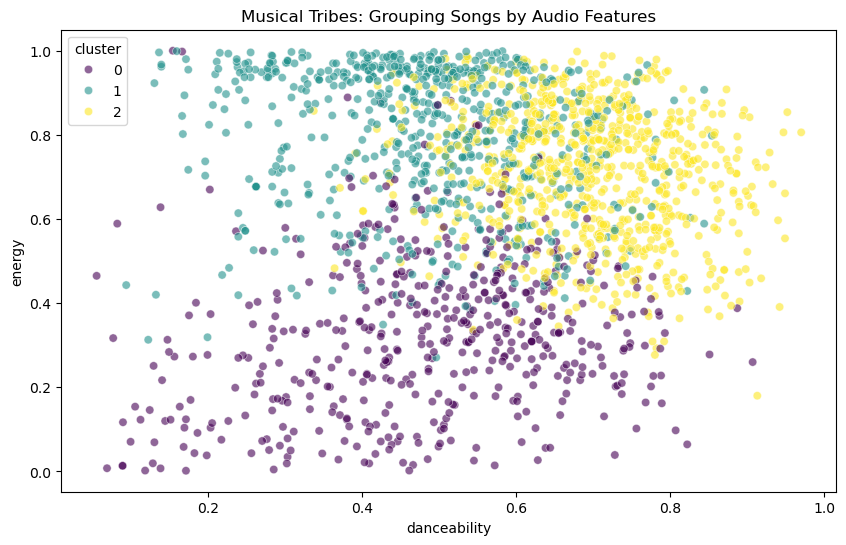

Average Feature Values per Cluster:
         danceability    energy  acousticness   valence
cluster                                                
0            0.478479  0.322768      0.763040  0.327181
1            0.483761  0.796214      0.074717  0.315858
2            0.693771  0.713924      0.232759  0.697386


In [47]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

#Scaling the data: use a subset of features that define a song's "vibe"
features_to_cluster = ['danceability', 'energy', 'acousticness', 'valence']
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[features_to_cluster])

#Run K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(scaled_data)

#Visualize "Musical Tribes"
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(2000), x='danceability', y='energy', 
                hue='cluster', palette='viridis', alpha=0.6)
plt.title('Musical Tribes: Grouping Songs by Audio Features')
plt.show()

#Interpret clusters
print("Average Feature Values per Cluster:")
print(df.groupby('cluster')[features_to_cluster].mean())

**Musical Tribes Breakdown**
- Cluster 0 | High Acousticness (0.76), Lowest Energy | "The Unplugged / Chill" (Think: Folk, Classical, or Acoustic covers)
- Cluster 1 | Highest Energy (0.80), Lowest Valence & Acousticness | "The High-Energy / Darker" (Think: Metal, Hard Rock, or Techno) 
- Cluster 2 | Highest Danceability (0.69) & Valence (0.69) | "The Feel-Good Hits" (Think: Pop, Funk, or Disco) 

## Text Analysis: Album Name Word Cloud

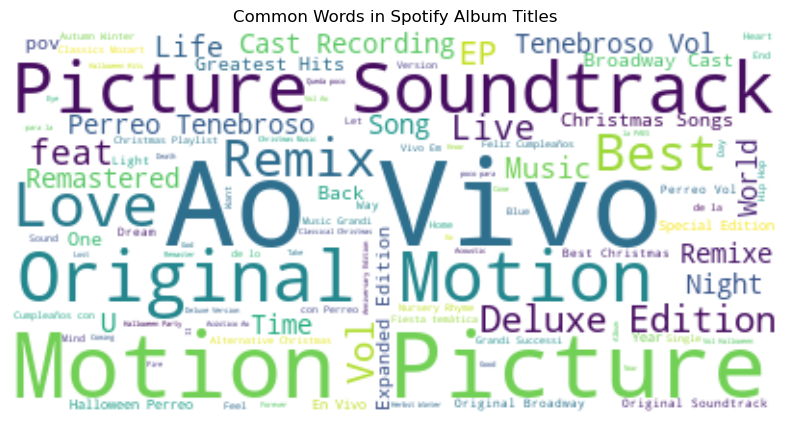

In [41]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(name for name in df.album_name.astype(str))
wordcloud = WordCloud(background_color="white", max_words=100).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Common Words in Spotify Album Titles")
plt.show()